In [1]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning & Data Preprocessing
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix

# Deep Learning Framework
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# ==============================================================================
# 2. DATA LOADING & PREPROCESSING
# ==============================================================================
print("--- ⚙️ INITIALIZING DATA PIPELINE ---")

# Loading the Wisconsin Breast Cancer Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target # 0: Malignant, 1: Benign

# Splitting data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalization (CRITICAL FOR HARDWARE):
# Using MinMaxScaler to bound features between 0 and 1.
# This prevents mathematical overflow during fixed-point quantization on the FPGA.
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data Pipeline Ready!")
print(f"   Training samples: {X_train_scaled.shape[0]}")
print(f"   Testing samples: {X_test_scaled.shape[0]}")
print(f"   Features per sample: {X_train_scaled.shape[1]}")

--- ⚙️ INITIALIZING DATA PIPELINE ---
✅ Data Pipeline Ready!
   Training samples: 455
   Testing samples: 114
   Features per sample: 30


In [2]:
# ==============================================================================
# 3. NEURAL NETWORK ARCHITECTURE [30-5-1]
# ==============================================================================
print("\n--- 🧠 BUILDING HARDWARE-TARGETED MLP ---")

# Defining the exact topology to match the VHDL synthesis parameters
# Architecture: 30 Inputs -> 5 Hidden Neurons -> 1 Output Neuron
model = Sequential()

# Hidden Layer (5 Neurons)
# The input_shape is strictly 30 (our medical features).
# We use 'relu' as it is computationally cheaper to implement on an FPGA than Sigmoid/Tanh.
model.add(Dense(5, input_shape=(X_train_scaled.shape[1],), activation='relu', name='Hidden_Layer'))

# Output Layer (1 Neuron)
# Using 'sigmoid' for binary classification (Malignant vs Benign)
model.add(Dense(1, activation='sigmoid', name='Output_Layer'))

# Compiling the model
# Adam optimizer is used for faster convergence and better final weights.
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==============================================================================
# 4. MODEL TRAINING
# ==============================================================================
print("\n--- 🚀 TRAINING THE GOLDEN MODEL ---")

# Training the network and saving the history for visualization
history = model.fit(X_train_scaled, y_train,
                    epochs=150,           # Sufficient epochs for convergence
                    batch_size=16,        # Small batch size for better generalization
                    validation_split=0.2, # Reserving 20% of training data for validation
                    verbose=1)

print("✅ Training Complete!")


--- 🧠 BUILDING HARDWARE-TARGETED MLP ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden_Layer (Dense)            │ (None, 5)              │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)


--- 🚀 TRAINING THE GOLDEN MODEL ---
Epoch 1/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4066 - loss: 0.7003 - val_accuracy: 0.4396 - val_loss: 0.6969
Epoch 2/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4615 - loss: 0.6868 - val_accuracy: 0.5385 - val_loss: 0.6839
Epoch 3/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6264 - loss: 0.6712 - val_accuracy: 0.7582 - val_loss: 0.6636
Epoch 4/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8407 - loss: 0.6476 - val_accuracy: 0.8132 - val_loss: 0.6407
Epoch 5/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8956 - loss: 0.6250 - val_accuracy: 0.8462 - val_loss: 0.6219
Epoch 6/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8874 - loss: 0.6045 - val_accuracy: 0.8352 - val_loss: 0.6011
Epoch 7/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8846 - loss: 0.5832 - val_accuracy: 0.8462 - val_loss: 0.5790
Epoch 8/150
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8956 - l


--- 📊 EVALUATING MODEL PERFORMANCE ---


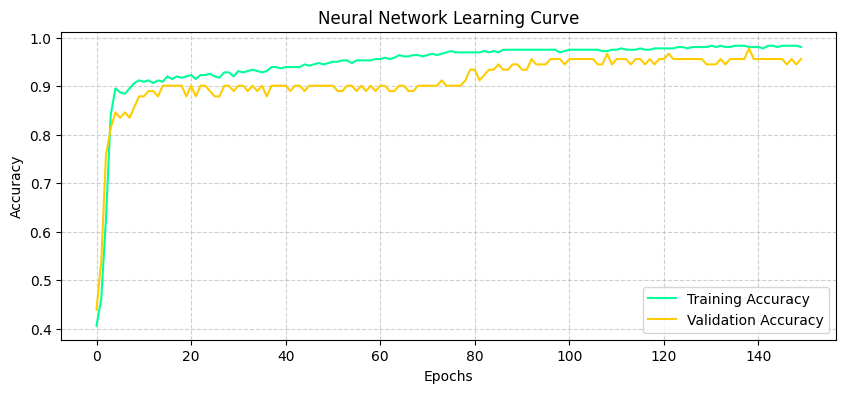

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


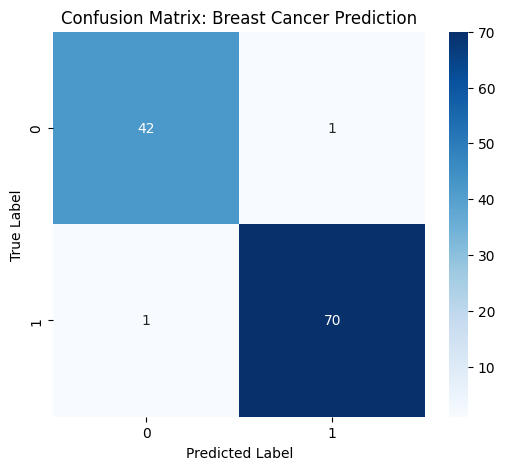

🎯 Final Test Accuracy (Golden Model): 98.25%


In [3]:
# ==============================================================================
# 5. MODEL EVALUATION & CLINICAL VALIDATION
# ==============================================================================
print("\n--- 📊 EVALUATING MODEL PERFORMANCE ---")

# Plotting the Training and Validation Accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['accuracy'], label='Training Accuracy', color='#00ff99')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='#ffcc00')
plt.title('Neural Network Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Generating Predictions for the Confusion Matrix
# We use 0.5 as the threshold for the Sigmoid output
predictions = (model.predict(X_test_scaled) > 0.5).astype("int32")

# Confusion Matrix Evaluation
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Breast Cancer Prediction')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Evaluating final numerical accuracy on the test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"🎯 Final Test Accuracy (Golden Model): {test_acc * 100:.2f}%")


--- ⚙️ EXTRACTING WEIGHTS FOR FPGA (VHDL) ---
Mean Rounding Noise: 1.82e-08
Max Rounding Noise: 1.06e-07


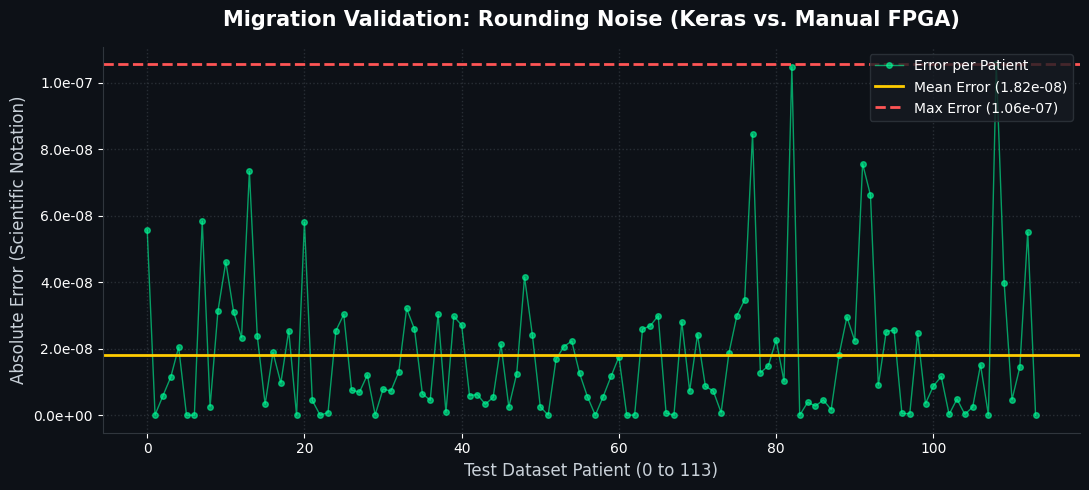


--- 💾 EXPORTING VHDL INTERFACE ---
✅ SUCCESS! Hardware interface file 'pesosVieses.txt' generated securely.


In [5]:
# ==============================================================================
# 6. HARDWARE SYNTHESIS PREPARATION (MATHEMATICAL PARITY)
# ==============================================================================
print("\n--- ⚙️ EXTRACTING WEIGHTS FOR FPGA (VHDL) ---")

# Extracting weights and biases from the trained Keras model
W1, b1 = model.layers[0].get_weights()
W2, b2 = model.layers[1].get_weights()

# Rebuilding the Neural Network purely with NumPy (Hardware Simulation)
# This proves that our VHDL implementation will exactly match Keras' backend
def relu(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Manual Feedforward pass (simulating the FPGA behavior)
Z1_manual = np.dot(X_test_scaled, W1) + b1
A1_manual = relu(Z1_manual)

Z2_manual = np.dot(A1_manual, W2) + b2
predictions_manual = sigmoid(Z2_manual)

# Calculating Absolute Error between Keras Backend and Manual Math
keras_predictions = model.predict(X_test_scaled, verbose=0)
absolute_errors = np.abs(keras_predictions.flatten() - predictions_manual.flatten())

mean_error = np.mean(absolute_errors)
max_error = np.max(absolute_errors)

print(f"Mean Rounding Noise: {mean_error:.2e}")
print(f"Max Rounding Noise: {max_error:.2e}")

# ==============================================================================
# 7. VISUALIZING HARDWARE MIGRATION NOISE
# ==============================================================================
# Plotting the mathematical parity to prove hardware-readiness
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')

pacientes_id = range(len(absolute_errors))
ax.plot(pacientes_id, absolute_errors, color='#00ff99', alpha=0.6, marker='o', markersize=4, linewidth=1, label='Error per Patient')

ax.axhline(mean_error, color='#ffcc00', linestyle='-', linewidth=2, label=f'Mean Error ({mean_error:.2e})')
ax.axhline(max_error, color='#ff5555', linestyle='--', linewidth=2, label=f'Max Error ({max_error:.2e})')

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"{x:.1e}"))
ax.set_title('Migration Validation: Rounding Noise (Keras vs. Manual FPGA)', fontsize=15, fontweight='bold', color='#ffffff', pad=15)
ax.set_xlabel(f'Test Dataset Patient (0 to {len(absolute_errors)-1})', fontsize=12, color='#c9d1d9')
ax.set_ylabel('Absolute Error (Scientific Notation)', fontsize=12, color='#c9d1d9')
ax.grid(color='#30363d', linestyle=':', linewidth=1, alpha=0.8)
ax.legend(loc='upper right', facecolor='#161b22', edgecolor='#30363d', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#30363d')
ax.spines['bottom'].set_color('#30363d')
plt.tight_layout()
plt.show()

# ==============================================================================
# 8. EXPORTING VHDL INTERFACE (BIAS TRICK & SAFE FORMATTING)
# ==============================================================================
from google.colab import files

print("\n--- 💾 EXPORTING VHDL INTERFACE ---")

# Applying the "Bias Trick" (Augmented Matrix with x0 = -1)
# Inverting bias sign (-b) to match the legacy VHDL translator logic
W1_pires = np.hstack([-b1.reshape(-1, 1), W1.T])
W2_pires = np.hstack([-b2.reshape(-1, 1), W2.T])

def format_interface_matrix_safe(matriz, nome_camada):
    linhas_texto = [nome_camada]
    for i, linha in enumerate(matriz):
        linha_plana = linha.flatten()
        linha_str = " ".join([f"{float(val):.6f}" for val in linha_plana])
        # STRICT SAFEGUARD: Removing hidden newline characters to prevent VHDL crashes
        linha_str = linha_str.replace('\n', '').replace('\r', '')

        if len(matriz) == 1:
            linhas_texto.append(f"([{linha_str}])")
        elif i == 0:
            linhas_texto.append(f"([{linha_str}]")
        elif i == len(matriz) - 1:
            linhas_texto.append(f" [{linha_str}])")
        else:
            linhas_texto.append(f" [{linha_str}]")

    return "\n".join(linhas_texto) + "\n"

# Generating the robust file
vhdl_basis = 'pesosVieses.txt'
with open(vhdl_basis, 'w', encoding='utf-8') as f:
    f.write("[30-5-1]\n")
    f.write(format_interface_matrix_safe(W1_pires, "W1"))
    f.write(format_interface_matrix_safe(W2_pires, "W2"))

print(f"✅ SUCCESS! Hardware interface file '{vhdl_basis}' generated securely.")
# Uncomment the line below to download the file directly in Colab
# files.download(vhdl_basis)